In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Pure matplotlib display (no cv2 display or color conversion)
def show(img, title=None, cmap=None):
    plt.figure(figsize=(6,4))
    if img.ndim == 2:
        plt.imshow(img, cmap=cmap or "gray")
    else:
        plt.imshow(img)  # assume already RGB
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()

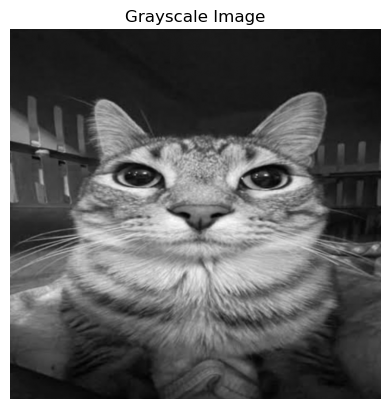

In [2]:
image_data = cv2.imread("newcat.png", 0)

plt.imshow(image_data, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

In [3]:
image_data.shape

(1077, 1080)

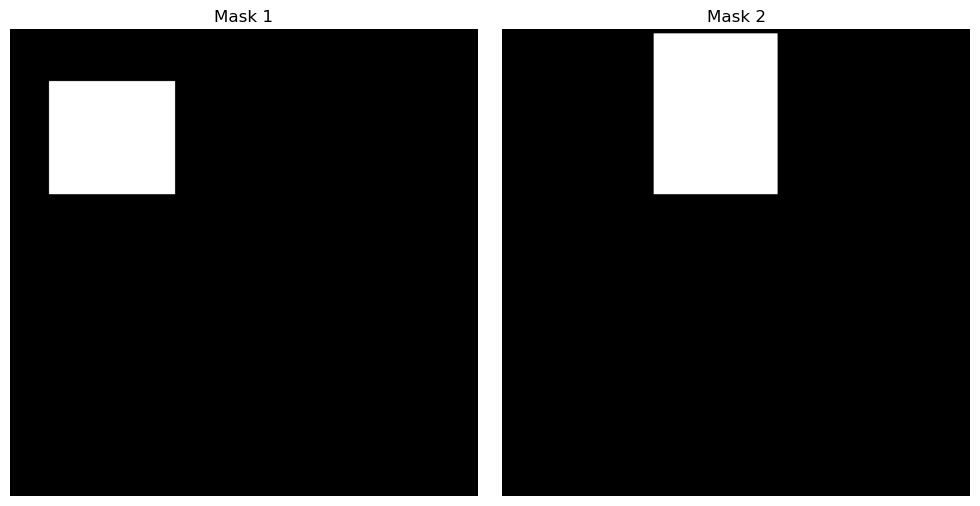

In [4]:
# initialize masks
mask1 = np.zeros(image_data.shape[:2], np.uint8)
mask2 = np.zeros(image_data.shape[:2], np.uint8)

# draw rectangles
cv2.rectangle(mask1, (90, 120), (380, 380), 255, -1)
cv2.rectangle(mask2, (350, 10), (635, 380), 255, -1)

# display using matplotlib
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(mask1, cmap='gray')
plt.title("Mask 1")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask2, cmap='gray')
plt.title("Mask 2")
plt.axis("off")

plt.tight_layout()
plt.show()

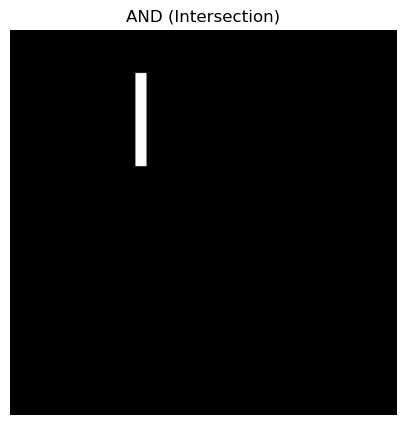

In [5]:
# Shows only where they intersect
And = cv2.bitwise_and(mask1, mask2)

plt.figure(figsize=(5,5))
plt.imshow(And, cmap='gray')
plt.title("AND (Intersection)")
plt.axis("off")
plt.show()

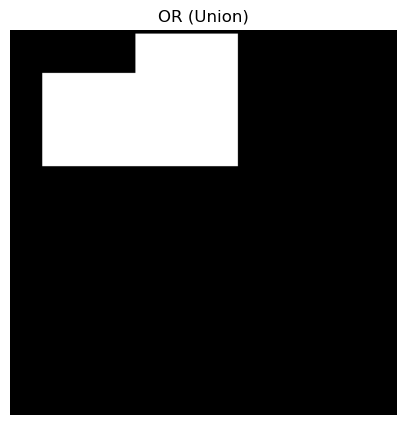

In [6]:
# Shows where either mask1 or mask2 is white
bitwiseOr = cv2.bitwise_or(mask1, mask2)

plt.figure(figsize=(5,5))
plt.imshow(bitwiseOr, cmap='gray')
plt.title("OR (Union)")
plt.axis("off")
plt.show()

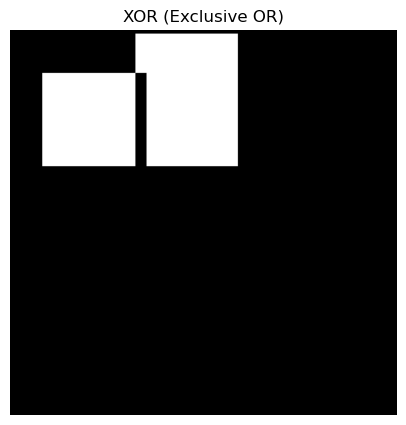

In [7]:
# Shows where either exists by itself (non-overlapping regions)
bitwiseXor = cv2.bitwise_xor(mask1, mask2)

plt.figure(figsize=(5,5))
plt.imshow(bitwiseXor, cmap='gray')
plt.title("XOR (Exclusive OR)")
plt.axis("off")
plt.show()

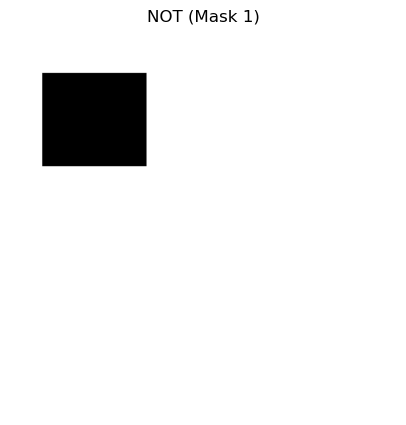

In [8]:
# Shows everything that isn't part of mask1
bitwiseNot_sq = cv2.bitwise_not(mask1)

plt.figure(figsize=(5,5))
plt.imshow(bitwiseNot_sq, cmap='gray')
plt.title("NOT (Mask 1)")
plt.axis("off")
plt.show()

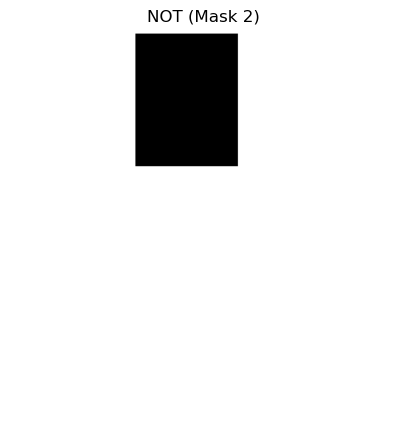

In [9]:
# Invert mask2
bitwiseNot_ell = cv2.bitwise_not(mask2)

plt.figure(figsize=(5,5))
plt.imshow(bitwiseNot_ell, cmap='gray')
plt.title("NOT (Mask 2)")
plt.axis("off")
plt.show()

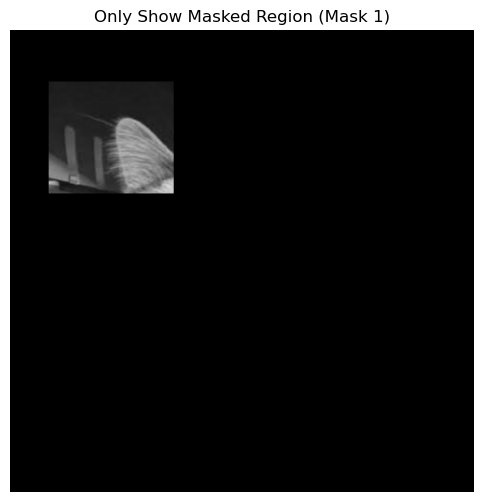

In [10]:
# Apply mask1 to the original image
puppy = cv2.bitwise_and(image_data, image_data, mask=mask1)

# Convert BGR to RGB for correct color display
puppy_rgb = cv2.cvtColor(puppy, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(puppy_rgb)
plt.title("Only Show Masked Region (Mask 1)")
plt.axis("off")
plt.show()

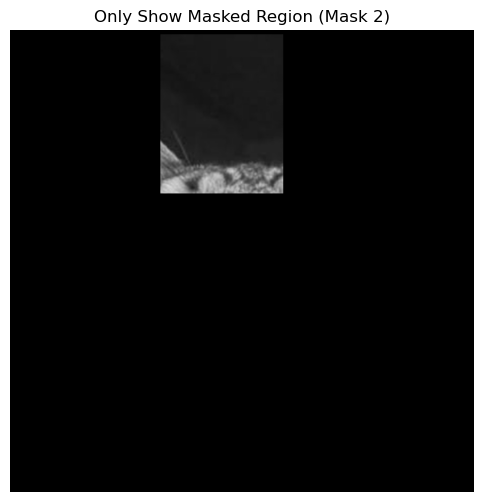

In [11]:
# Apply mask2 to the original image
dog = cv2.bitwise_and(image_data, image_data, mask=mask2)

# Convert BGR to RGB for correct color display
dog_rgb = cv2.cvtColor(dog, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(dog_rgb)
plt.title("Only Show Masked Region (Mask 2)")
plt.axis("off")
plt.show()

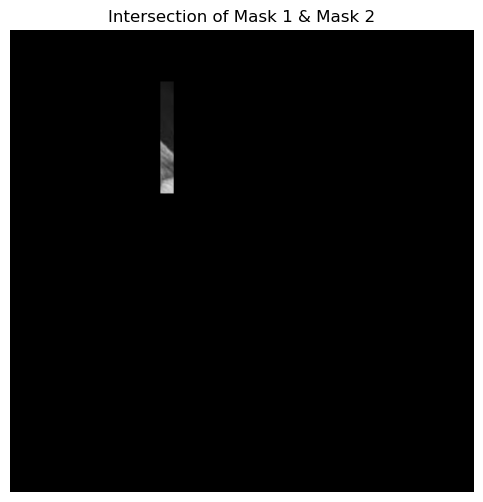

In [12]:
# Apply intersection mask (And) to the original image
dog = cv2.bitwise_and(image_data, image_data, mask=And)

# Convert BGR to RGB
dog_rgb = cv2.cvtColor(dog, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(dog_rgb)
plt.title("Intersection of Mask 1 & Mask 2")
plt.axis("off")
plt.show()

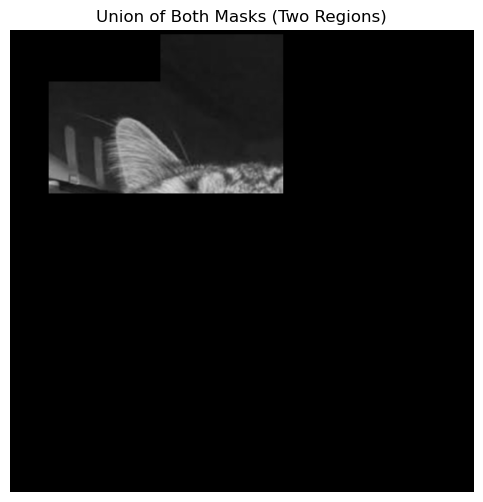

In [13]:
# Apply OR mask to the original image
dog = cv2.bitwise_and(image_data, image_data, mask=bitwiseOr)

# Convert BGR → RGB for proper display
dog_rgb = cv2.cvtColor(dog, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(dog_rgb)
plt.title("Union of Both Masks (Two Regions)")
plt.axis("off")
plt.show()
     

## TASK 1 — Create a circular mask (easy)

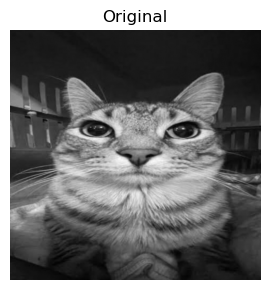

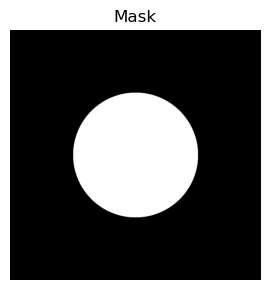

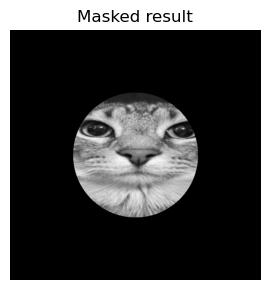

In [16]:
def show(img, title="", cmap=None):
    plt.figure(figsize=(4,3))
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

img = cv2.imread("newcat.png", cv2.IMREAD_GRAYSCALE)
h, w = img.shape

mask = np.zeros((h, w), dtype=np.uint8)
cx, cy = w // 2, h // 2
r = min(h, w) // 4
cv2.circle(mask, (cx, cy), r, 255, -1)

# Apply mask
masked = cv2.bitwise_and(img, img, mask=mask)

# Display
show(img,    "Original",      cmap="gray")
show(mask,   "Mask",          cmap="gray")
show(masked, "Masked result", cmap="gray")

## TASK 2 — Reconstruct an image from selected bit-planes

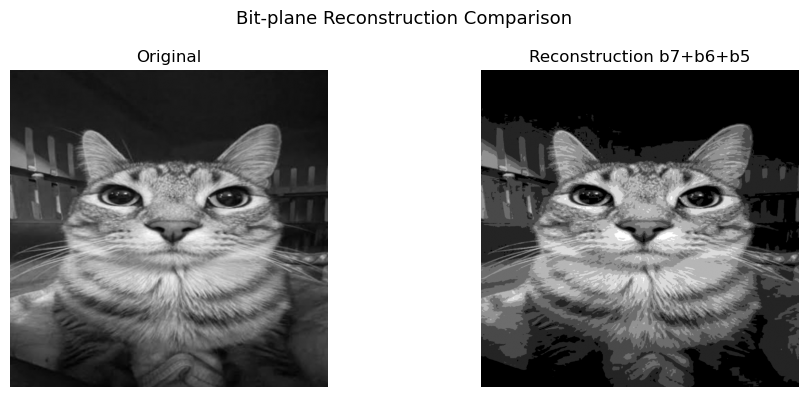

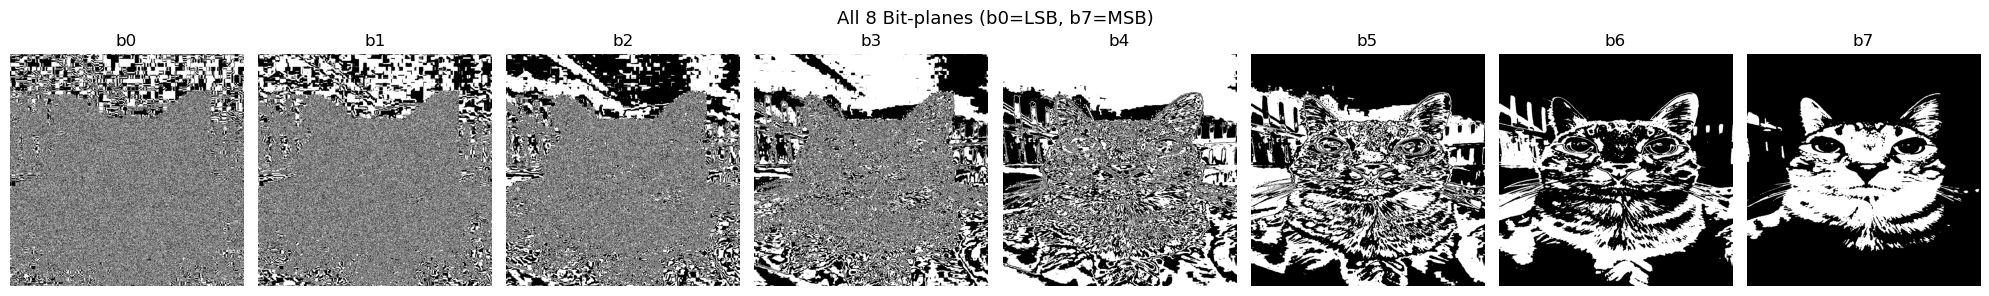

Max pixel error : 31
Mean pixel error: 17.26
Planes used     : b7 (128) + b6 (64) + b5 (32) = max 224 intensity levels


In [17]:
def show(img, title="", cmap=None):
    plt.figure(figsize=(4,3))
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

img = cv2.imread("newcat.png", cv2.IMREAD_GRAYSCALE)

# planes[i] contains only the i-th bit (values 0 or 1)
planes = [(img >> i) & 1 for i in range(8)]

recon = np.zeros_like(img, dtype=np.uint8)
for i in [7, 6, 5]:
    recon = recon + (planes[i].astype(np.uint8) << i)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img,   cmap="gray"); axes[0].set_title("Original");              axes[0].axis("off")
axes[1].imshow(recon, cmap="gray"); axes[1].set_title("Reconstruction b7+b6+b5"); axes[1].axis("off")
plt.suptitle("Bit-plane Reconstruction Comparison", fontsize=13)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 8, figsize=(20, 3))
for i in range(8):
    axes[i].imshow(planes[i], cmap="gray")
    axes[i].set_title(f"b{i}")
    axes[i].axis("off")
plt.suptitle("All 8 Bit-planes (b0=LSB, b7=MSB)", fontsize=13)
plt.tight_layout()
plt.show()

error = cv2.absdiff(img, recon)
print(f"Max pixel error : {error.max()}")
print(f"Mean pixel error: {error.mean():.2f}")
print(f"Planes used     : b7 (128) + b6 (64) + b5 (32) = max {128+64+32} intensity levels")

## TASK 3 — Histogram equalization comparison

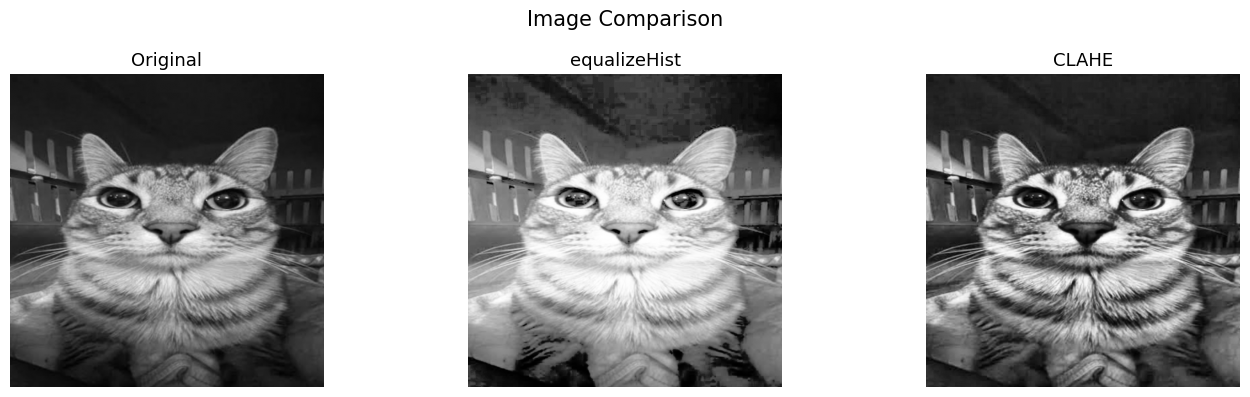

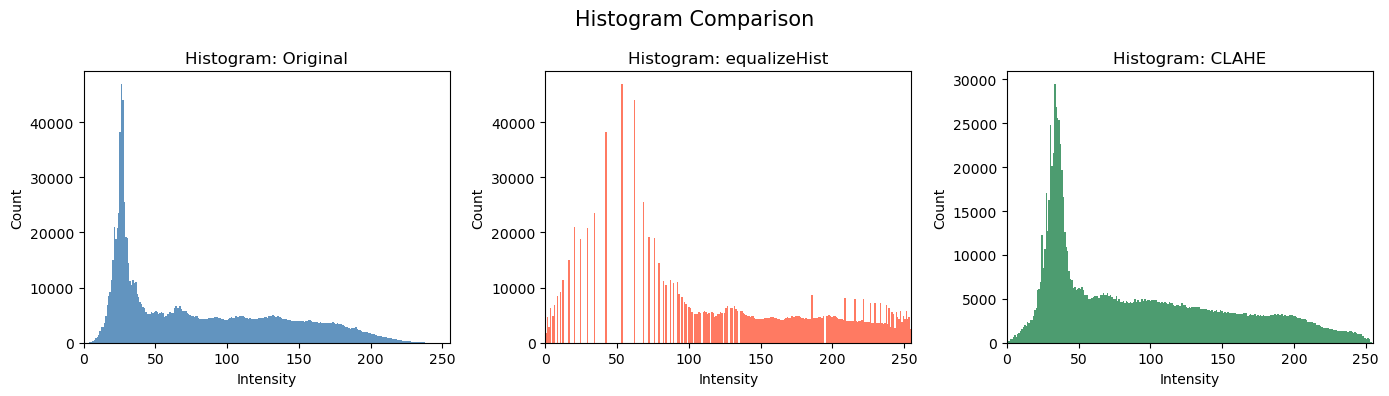

Method            Min   Max      Std     Mean
---------------------------------------------
Original            2   246    56.86    80.45
equalizeHist        0   255    72.78   128.75
CLAHE               0   254    63.14    92.34


In [25]:
img = cv2.imread("newcat.png", cv2.IMREAD_GRAYSCALE)

eq    = cv2.equalizeHist(img)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(img)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, image, title in zip(axes,
                             [img, eq, clahe],
                             ["Original", "equalizeHist", "CLAHE"]):
    ax.imshow(image, cmap="gray")
    ax.set_title(title, fontsize=13)
    ax.axis("off")
plt.suptitle("Image Comparison", fontsize=15)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
colors = ["steelblue", "tomato", "seagreen"]
labels = ["Original", "equalizeHist", "CLAHE"]

for ax, image, title, color in zip(axes, [img, eq, clahe], labels, colors):
    ax.hist(image.ravel(), bins=256, range=(0, 255), color=color, alpha=0.85)
    ax.set_title(f"Histogram: {title}", fontsize=12)
    ax.set_xlabel("Intensity")
    ax.set_ylabel("Count")
    ax.set_xlim(0, 255)

plt.suptitle("Histogram Comparison", fontsize=15)
plt.tight_layout()
plt.show()

print(f"{'Method':<15} {'Min':>5} {'Max':>5} {'Std':>8} {'Mean':>8}")
print("-" * 45)
for image, label in zip([img, eq, clahe], labels):
    print(f"{label:<15} {image.min():>5} {image.max():>5} {image.std():>8.2f} {image.mean():>8.2f}")

## TASK 4 — Gamma sweep (very easy)

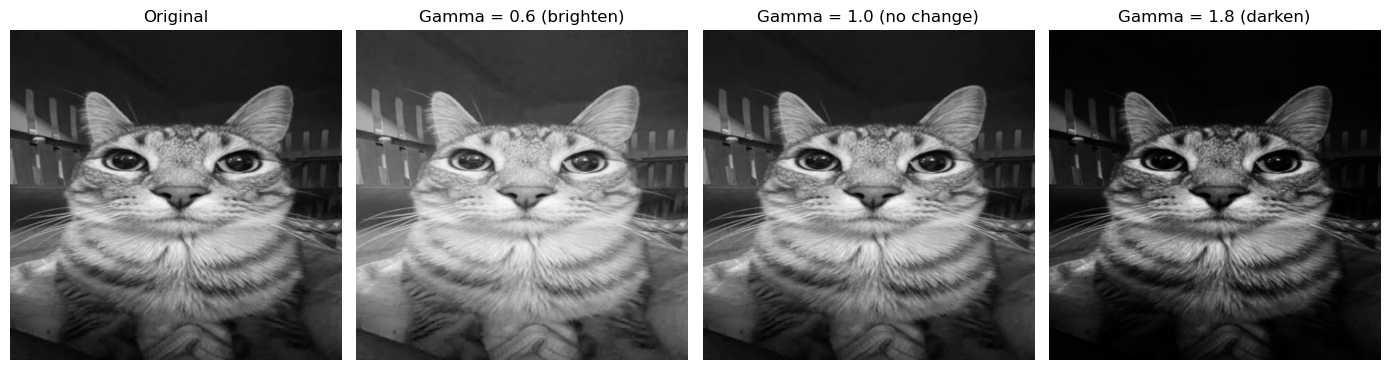

In [29]:
def apply_gamma(img, gamma):
    img_f = img.astype(np.float32) / 255.0
    out = np.power(img_f, gamma)
    return np.uint8(np.clip(out * 255.0, 0, 255))

img = cv2.imread("newcat.png", cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError("Image not found. Check the path.")

g_bright  = apply_gamma(img, 0.6)  # gamma < 1
g_same    = apply_gamma(img, 1.0)  # gamma = 1
g_darken  = apply_gamma(img, 1.8)  # gamma > 1

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

axes[0].imshow(img, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(g_bright, cmap="gray")
axes[1].set_title("Gamma = 0.6 (brighten)")
axes[1].axis("off")

axes[2].imshow(g_same, cmap="gray")
axes[2].set_title("Gamma = 1.0 (no change)")
axes[2].axis("off")

axes[3].imshow(g_darken, cmap="gray")
axes[3].set_title("Gamma = 1.8 (darken)")
axes[3].axis("off")

plt.tight_layout()
plt.show()

### TASK 1 — Circular Mask
Load a grayscale image, create a circular binary mask using cv2.circle(),
and apply it with cv2.bitwise_and() to keep only pixels inside the circle.
# TASK 2 — Bit-Plane Reconstruction
Decompose the image into 8 bit-planes using bitwise operations.
Reconstruct using only the top 3 planes (b7, b6, b5), which hold ~87.5%
of the intensity information — result is close but slightly posterized.
#
### TASK 3 — Histogram Equalization
# Enhance a low-contrast image using:
#   - equalizeHist : global stretch, can over-enhance
#   - CLAHE        : local tile-based, more natural result
Histograms are plotted to compare all three versions.

### TASK 4 — Gamma Correction
Apply output = input^gamma to adjust brightness:
- gamma < 1 : brightens
- gamma = 1 : no change
- gamma > 1 : darkens
